# Manufacturing Defect Classification
### Predicting whether a manufactured unit is defective


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as seaborn_plots

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)

import joblib

seaborn_plots.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

## Load the Dataset

In [2]:
manufacturing_data = pd.read_csv("data/manufacturing_defects.csv")
manufacturing_data.head()

,unit_id,production_line,process_temperature_celsius,process_pressure_bar,cycle_time_seconds,material_thickness_mm,machine_vibration_level,operator_experience_years,inspection_score,is_defective
0,UNIT_00000,Line_A,192.7,4.80,44.0,3.29,0.75,7,84.6,1
1,UNIT_00001,Line_C,170.9,5.97,40.5,3.54,2.23,5,79.0,1
2,UNIT_00002,Line_B,147.1,5.63,43.8,2.92,0.09,14,100.0,0
3,UNIT_00003,Line_B,158.8,4.02,43.6,2.67,0.27,6,82.8,1
4,UNIT_00004,Line_B,197.1,5.81,50.7,2.94,0.32,7,88.6,0


## Dataset Overview

In [3]:
print("Rows and columns:", manufacturing_data.shape)
print()
manufacturing_data.info()

Rows and columns: (6022, 10)

<class 'pandas.DataFrame'>
RangeIndex: 6022 entries, 0 to 6021
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   unit_id                      6022 non-null   str    
 1   production_line              6022 non-null   str    
 2   process_temperature_celsius  6022 non-null   float64
 3   process_pressure_bar         6022 non-null   float64
 4   cycle_time_seconds           6022 non-null   float64
 5   material_thickness_mm        6022 non-null   float64
 6   machine_vibration_level      6022 non-null   float64
 7   operator_experience_years    6022 non-null   int64  
 8   inspection_score             5972 non-null   float64
 9   is_defective                 6022 non-null   int64  
dtypes: float64(6), int64(2), str(2)
memory usage: 470.6 KB


In [4]:
manufacturing_data.describe()

,process_temperature_celsius,process_pressure_bar,cycle_time_seconds,material_thickness_mm,machine_vibration_level,operator_experience_years,inspection_score,is_defective
count,6022.000000,6022.000000,6022.000000,6022.000000,6022.000000,6022.000000,5972.000000,6022.000000
mean,180.076569,4.992350,45.227715,3.007869,0.801265,9.553969,84.815070,0.235304
std,11.991220,0.605925,6.022249,0.250087,0.578708,5.790163,7.718972,0.424224
min,127.300000,2.670000,22.800000,2.120000,0.000000,0.000000,54.500000,0.000000
25%,172.100000,4.590000,41.100000,2.840000,0.380000,5.000000,79.600000,0.000000
50%,179.900000,4.980000,45.200000,3.010000,0.665000,10.000000,84.800000,0.000000
75%,188.000000,5.397500,49.300000,3.170000,1.090000,15.000000,90.300000,0.000000
max,228.300000,7.490000,66.300000,3.830000,5.020000,19.000000,100.000000,1.000000


## Data Quality Checks

In [5]:
missing_value_counts = manufacturing_data.isnull().sum()
missing_value_counts[missing_value_counts > 0]

,0
inspection_score,50


In [6]:
number_of_duplicate_rows = manufacturing_data.duplicated().sum()
print("Duplicate rows found:", number_of_duplicate_rows)

Duplicate rows found: 22


In [7]:
class_distribution = manufacturing_data["is_defective"].value_counts(normalize=True) * 100
class_distribution

,proportion
is_defective,
0,76.469611
1,23.530389


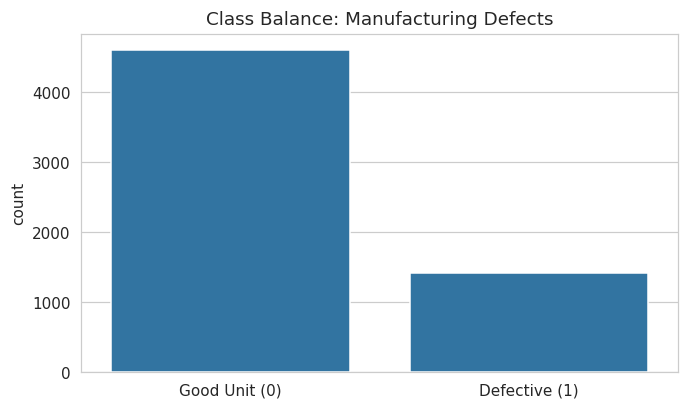

In [8]:
figure, axis = plt.subplots()
seaborn_plots.countplot(data=manufacturing_data, x="is_defective", ax=axis)
axis.set_xticks([0, 1])
axis.set_xticklabels(["Good Unit (0)", "Defective (1)"])
axis.set_title("Class Balance: Manufacturing Defects")
axis.set_xlabel("")
plt.show()

## Cleaning the Data

In [9]:
cleaned_manufacturing_data = manufacturing_data.copy()

median_inspection_score = cleaned_manufacturing_data["inspection_score"].median()
cleaned_manufacturing_data["inspection_score"] = cleaned_manufacturing_data["inspection_score"].fillna(median_inspection_score)

cleaned_manufacturing_data = cleaned_manufacturing_data.drop_duplicates()

print("Shape after cleaning:", cleaned_manufacturing_data.shape)
print("Remaining missing values:", cleaned_manufacturing_data.isnull().sum().sum())

Shape after cleaning: (6000, 10)
Remaining missing values: 0


## Exploratory Data Analysis

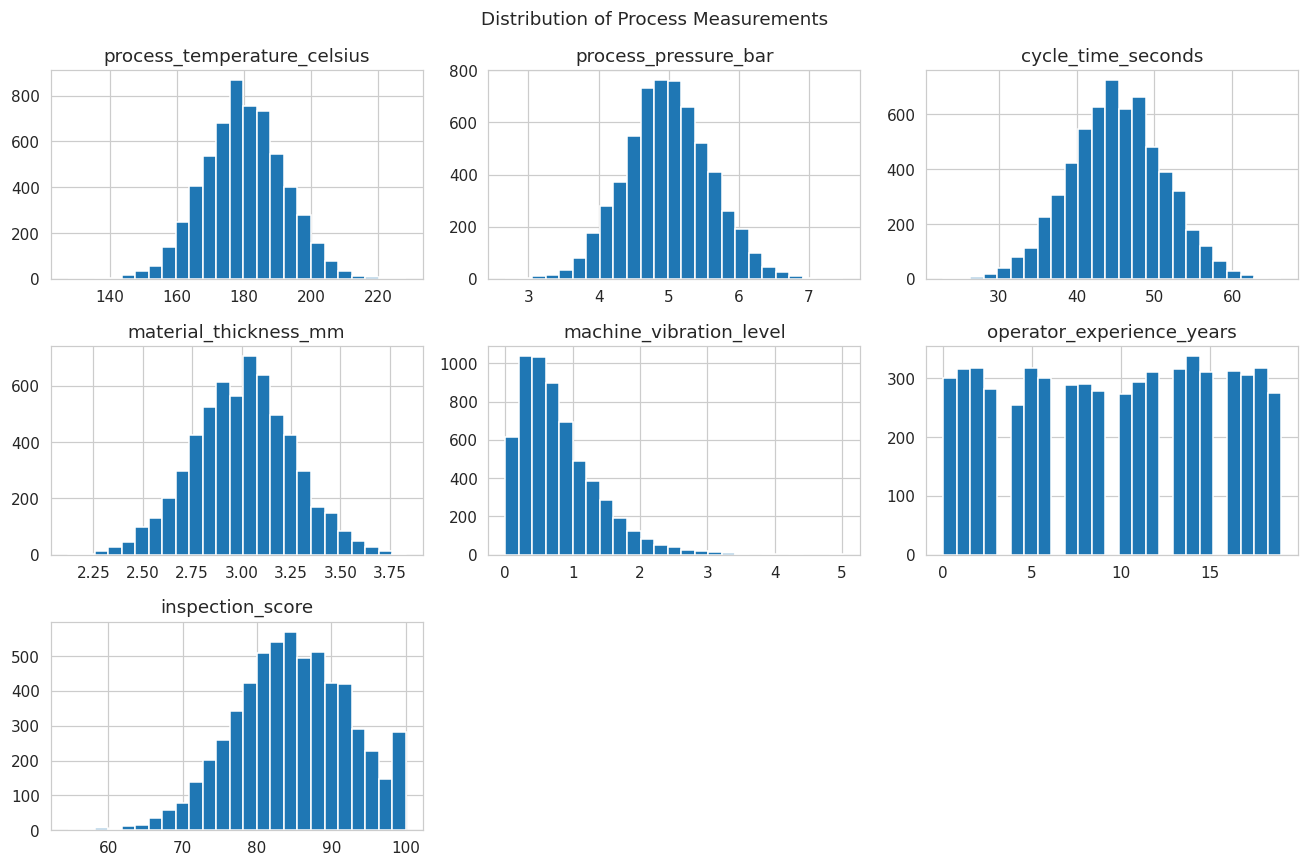

In [10]:
numerical_feature_columns = [
    "process_temperature_celsius", "process_pressure_bar", "cycle_time_seconds",
    "material_thickness_mm", "machine_vibration_level", "operator_experience_years", "inspection_score"
]

cleaned_manufacturing_data[numerical_feature_columns].hist(figsize=(12, 8), bins=25)
plt.suptitle("Distribution of Process Measurements")
plt.tight_layout()
plt.show()

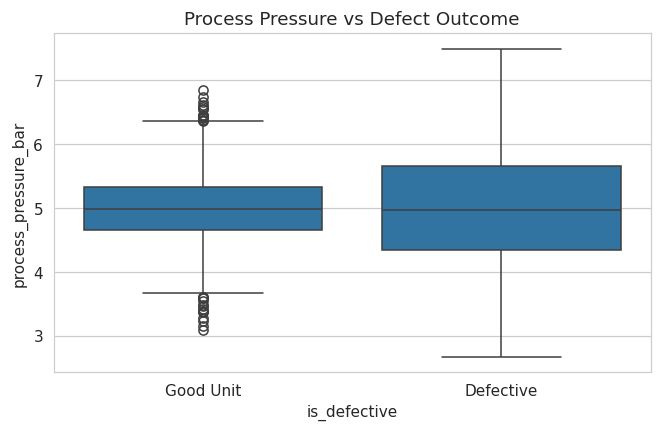

In [11]:
figure, axis = plt.subplots(figsize=(7, 4))
seaborn_plots.boxplot(
    data=cleaned_manufacturing_data, x="is_defective", y="process_pressure_bar", ax=axis
)
axis.set_xticks([0, 1])
axis.set_xticklabels(["Good Unit", "Defective"])
axis.set_title("Process Pressure vs Defect Outcome")
plt.show()

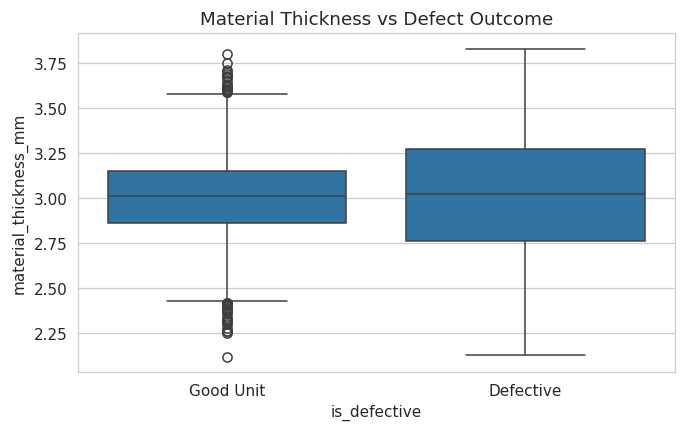

In [12]:
figure, axis = plt.subplots(figsize=(7, 4))
seaborn_plots.boxplot(
    data=cleaned_manufacturing_data, x="is_defective", y="material_thickness_mm", ax=axis
)
axis.set_xticks([0, 1])
axis.set_xticklabels(["Good Unit", "Defective"])
axis.set_title("Material Thickness vs Defect Outcome")
plt.show()

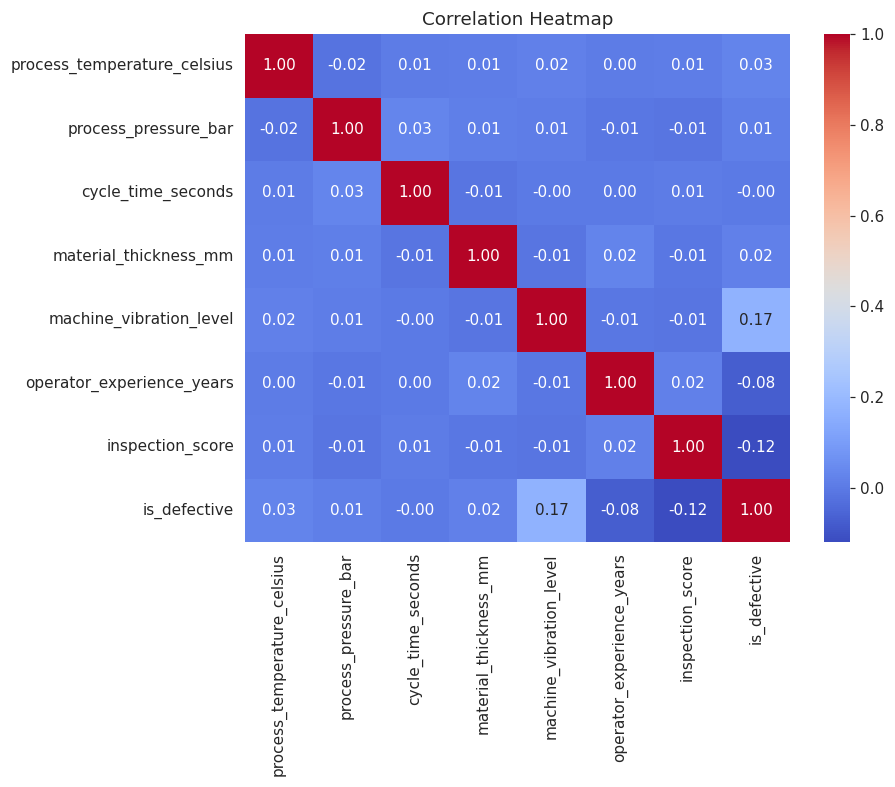

In [13]:
correlation_matrix = cleaned_manufacturing_data[numerical_feature_columns + ["is_defective"]].corr()

figure, axis = plt.subplots(figsize=(8, 6))
seaborn_plots.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=axis)
axis.set_title("Correlation Heatmap")
plt.show()

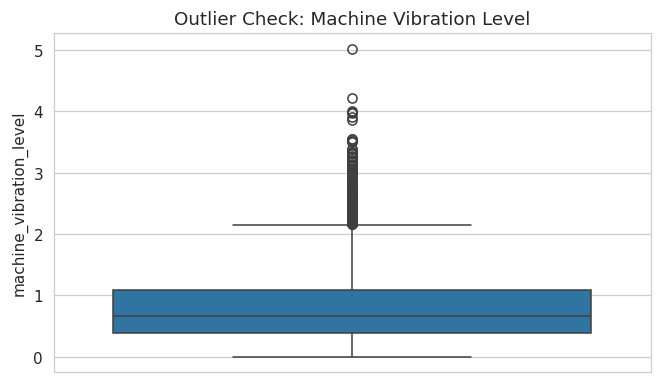

In [14]:
figure, axis = plt.subplots(figsize=(7, 4))
seaborn_plots.boxplot(data=cleaned_manufacturing_data, y="machine_vibration_level", ax=axis)
axis.set_title("Outlier Check: Machine Vibration Level")
plt.show()

**Observations from the EDA:**
- `process_pressure_bar` and `material_thickness_mm` show the clearest separation between good and
  defective units — units furthest from the target pressure (5.0 bar) and target thickness (3.0 mm) are
  more likely to be defective.
- `machine_vibration_level` trends higher among defective units, which matches real-world intuition:
  excess vibration during production tends to introduce flaws.
- `operator_experience_years` and `inspection_score` trend slightly negative with defects, i.e. more
  experienced operators and higher inspection scores are mildly protective.
- The classes are imbalanced (roughly 76% good vs 24% defective), so accuracy alone is not a reliable
  metric — precision, recall and F1-score are tracked as well.

## Feature Engineering

In [15]:
model_ready_data = cleaned_manufacturing_data.drop(columns=["unit_id"])

production_line_encoder = LabelEncoder()
model_ready_data["production_line_encoded"] = production_line_encoder.fit_transform(model_ready_data["production_line"])
model_ready_data = model_ready_data.drop(columns=["production_line"])

model_ready_data.head()

,process_temperature_celsius,process_pressure_bar,cycle_time_seconds,material_thickness_mm,machine_vibration_level,operator_experience_years,inspection_score,is_defective,production_line_encoded
0,192.7,4.80,44.0,3.29,0.75,7,84.6,1,0
1,170.9,5.97,40.5,3.54,2.23,5,79.0,1,2
2,147.1,5.63,43.8,2.92,0.09,14,100.0,0,1
3,158.8,4.02,43.6,2.67,0.27,6,82.8,1,1
4,197.1,5.81,50.7,2.94,0.32,7,88.6,0,1


## Train-Test Split

In [16]:
feature_columns = [
    "process_temperature_celsius", "process_pressure_bar", "cycle_time_seconds",
    "material_thickness_mm", "machine_vibration_level", "operator_experience_years",
    "inspection_score", "production_line_encoded"
]

feature_matrix = model_ready_data[feature_columns]
target_vector = model_ready_data["is_defective"]

features_train, features_test, target_train, target_test = train_test_split(
    feature_matrix, target_vector, test_size=0.2, random_state=42, stratify=target_vector
)

print("Training rows:", features_train.shape[0])
print("Testing rows:", features_test.shape[0])

Training rows: 4800
Testing rows: 1200


In [17]:
feature_scaler = StandardScaler()
features_train_scaled = feature_scaler.fit_transform(features_train)
features_test_scaled = feature_scaler.transform(features_test)

## Model Development

In [18]:
logistic_regression_model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
logistic_regression_model.fit(features_train_scaled, target_train)

logistic_regression_predictions = logistic_regression_model.predict(features_test_scaled)
logistic_regression_probabilities = logistic_regression_model.predict_proba(features_test_scaled)[:, 1]

In [19]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=6, class_weight="balanced", random_state=42
)
decision_tree_model.fit(features_train, target_train)

decision_tree_predictions = decision_tree_model.predict(features_test)
decision_tree_probabilities = decision_tree_model.predict_proba(features_test)[:, 1]

## Evaluation

In [20]:
def summarize_model_performance(model_name, true_labels, predicted_labels, predicted_probabilities):
    performance_summary = {
        "Model": model_name,
        "Accuracy": accuracy_score(true_labels, predicted_labels),
        "Precision": precision_score(true_labels, predicted_labels),
        "Recall": recall_score(true_labels, predicted_labels),
        "F1-Score": f1_score(true_labels, predicted_labels),
        "ROC-AUC": roc_auc_score(true_labels, predicted_probabilities),
    }
    return performance_summary


logistic_regression_summary = summarize_model_performance(
    "Logistic Regression", target_test, logistic_regression_predictions, logistic_regression_probabilities
)
decision_tree_summary = summarize_model_performance(
    "Decision Tree", target_test, decision_tree_predictions, decision_tree_probabilities
)

model_comparison_table = pd.DataFrame([logistic_regression_summary, decision_tree_summary]).set_index("Model")
model_comparison_table.round(3)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.608,0.311,0.550,0.397,0.625
Decision Tree,0.677,0.386,0.638,0.481,0.705


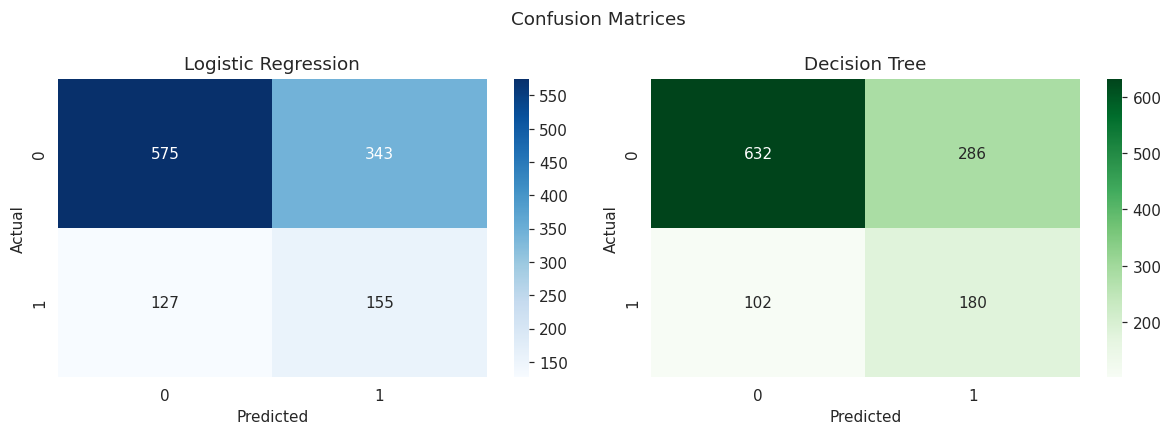

In [21]:
figure, (axis_one, axis_two) = plt.subplots(1, 2, figsize=(11, 4))

logistic_regression_confusion = confusion_matrix(target_test, logistic_regression_predictions)
seaborn_plots.heatmap(logistic_regression_confusion, annot=True, fmt="d", cmap="Blues", ax=axis_one)
axis_one.set_title("Logistic Regression")
axis_one.set_xlabel("Predicted")
axis_one.set_ylabel("Actual")

decision_tree_confusion = confusion_matrix(target_test, decision_tree_predictions)
seaborn_plots.heatmap(decision_tree_confusion, annot=True, fmt="d", cmap="Greens", ax=axis_two)
axis_two.set_title("Decision Tree")
axis_two.set_xlabel("Predicted")
axis_two.set_ylabel("Actual")

plt.suptitle("Confusion Matrices")
plt.tight_layout()
plt.show()

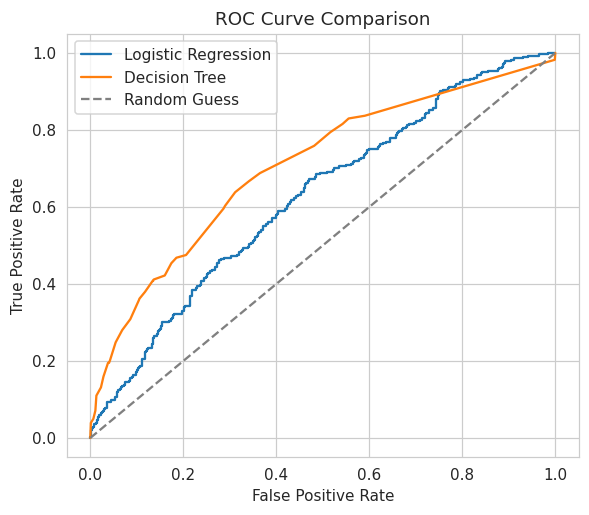

In [22]:
logistic_false_positive_rate, logistic_true_positive_rate, _ = roc_curve(
    target_test, logistic_regression_probabilities
)
tree_false_positive_rate, tree_true_positive_rate, _ = roc_curve(
    target_test, decision_tree_probabilities
)

figure, axis = plt.subplots(figsize=(6, 5))
axis.plot(logistic_false_positive_rate, logistic_true_positive_rate, label="Logistic Regression")
axis.plot(tree_false_positive_rate, tree_true_positive_rate, label="Decision Tree")
axis.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
axis.set_xlabel("False Positive Rate")
axis.set_ylabel("True Positive Rate")
axis.set_title("ROC Curve Comparison")
axis.legend()
plt.show()

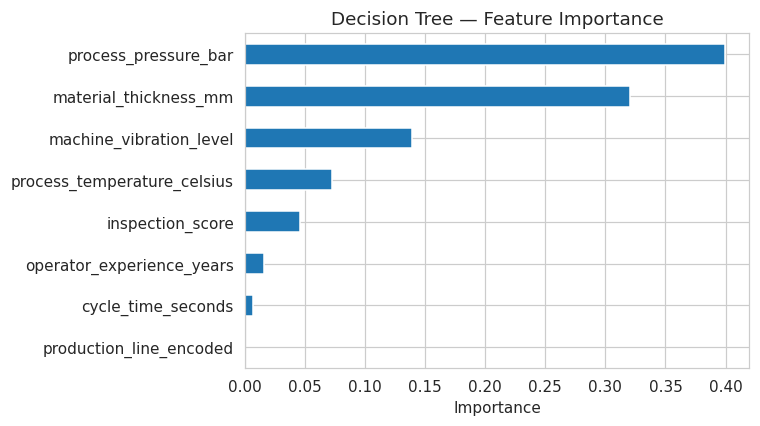

In [23]:
feature_importance_scores = pd.Series(
    decision_tree_model.feature_importances_, index=feature_columns
).sort_values(ascending=False)

figure, axis = plt.subplots(figsize=(7, 4))
feature_importance_scores.plot(kind="barh", ax=axis)
axis.invert_yaxis()
axis.set_title("Decision Tree — Feature Importance")
axis.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## Model Selection & Justification

Both models are compared on the table and charts above. The **Decision Tree** is selected as the final
model for the prototype because:

- It reaches a **higher recall on the defective class**, which matters most for a quality-control tool
  (a missed defect that reaches the customer is far costlier than an extra manual inspection).
- `process_pressure_bar` and `material_thickness_mm` dominate its feature importance, which matches the
  domain reasoning from the EDA — the model's decisions are explainable to a production engineer, not a
  black box.
- It does not require feature scaling at prediction time, which keeps the Streamlit prototype simpler.

Logistic Regression remains a useful, more stable baseline and is kept in the notebook for comparison and
in the technical paper's Results/Discussion section.

## Saving the Final Model for the Streamlit Prototype

In [24]:
joblib.dump(decision_tree_model, "models/defect_classifier_model.pkl")
joblib.dump(production_line_encoder, "models/production_line_encoder.pkl")
joblib.dump(feature_columns, "models/feature_columns.pkl")

print("Model, encoder and feature list saved to the models/ folder.")

Model, encoder and feature list saved to the models/ folder.


## Conclusion & Future Scope

A Decision Tree classifier, trained on process temperature, pressure, cycle time, material thickness,
vibration, operator experience and inspection score, distinguishes good and defective units with a
strong recall on the defective class, using only foundational, explainable methods.

**Limitations:** the dataset used here is a rule-based simulation rather than a live production-line
feed, so real deployment would need validation against actual sensor logs before being trusted to flag
real defects on a factory floor.

**Future scope:** incorporating real time-series sensor data (rather than single-point-in-time
readings), supplier/material-batch identifiers, and a cost-sensitive threshold tuned to the real cost of
a missed defect versus a false alarm could improve both accuracy and practical value.